In [ ]:
!pip install torch torchvision torchaudio datasets open3d wandb numpy tqdm huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 132.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.3 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import open3d as o3d
import wandb

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [ ]:
CFG = {
    "voxel_size": 64,
    "data_dir": "data/raw_10k",
    "batch_size": 4,
    "epochs": 200,
    "lr": 1e-4,
    "latent_dim": 256
}

In [ ]:
import os
from huggingface_hub import hf_hub_download
import glob
import zipfile
os.makedirs("data", exist_ok=True)

print("📥 Downloading raw point clouds (10k points per plant)...")
zip_path = hf_hub_download(
    repo_id="BGLab/MaizeField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="data"
)
print(f"✅ Downloaded: {zip_path}")

print("📦 Extracting...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(CFG["data_dir"])

ply_files = sorted(glob.glob(f"{CFG['data_dir']}/**/*.ply", recursive=True))
print(f"✅ Found {len(ply_files)} plant files.")

📥 Downloading raw point clouds (10k points per plant)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


datasets/FielGrwon_ZeaMays_RawPCD_10k.zi(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

✅ Downloaded: data/datasets/FielGrwon_ZeaMays_RawPCD_10k.zip
📦 Extracting...
✅ Found 1045 plant files.


In [ ]:
class MaizeVoxelDataset(Dataset):

    def __init__(self, ply_files, grid_size=64):

        self.files = ply_files
        self.grid_size = grid_size

    def normalize(self, points):

        centroid = np.mean(points, axis=0)
        points = points - centroid

        scale = np.max(np.linalg.norm(points, axis=1))
        points = points / scale

        return points

    def voxelize(self, points):

        grid = np.zeros((self.grid_size,
                         self.grid_size,
                         self.grid_size))

        coords = (points + 1) / 2
        coords = coords * (self.grid_size - 1)
        coords = coords.astype(int)

        coords = np.clip(coords, 0, self.grid_size - 1)

        grid[coords[:,0], coords[:,1], coords[:,2]] = 1

        return grid

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        path = self.files[idx]

        pcd = o3d.io.read_point_cloud(path)
        points = np.asarray(pcd.points)

        points = self.normalize(points)

        voxels = self.voxelize(points)

        voxels = torch.tensor(voxels, dtype=torch.float32)

        voxels = voxels.unsqueeze(0)

        return voxels

In [ ]:
dataset = MaizeVoxelDataset(
    ply_files,
    grid_size=CFG["voxel_size"]
)

loader = DataLoader(
    dataset,
    batch_size=CFG["batch_size"],
    shuffle=True
)

In [ ]:
class VoxelEncoder(nn.Module):

    def __init__(self, latent_dim=256):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv3d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv3d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv3d(128, 256, 4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc = nn.Linear(256 * 4 * 4 * 4, latent_dim)

    def forward(self, x):

        x = self.conv(x)

        x = x.view(x.size(0), -1)

        z = self.fc(x)

        return z

In [ ]:
class VoxelDecoder(nn.Module):

    def __init__(self, latent_dim=256):

        super().__init__()

        self.fc = nn.Linear(latent_dim, 256 * 4 * 4 * 4)

        self.deconv = nn.Sequential(

            nn.ConvTranspose3d(256,128,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose3d(128,64,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose3d(64,32,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose3d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):

        x = self.fc(z)

        x = x.view(-1,256,4,4,4)

        x = self.deconv(x)

        return x

In [ ]:
class VoxelAutoencoder(nn.Module):

    def __init__(self, latent_dim=256):

        super().__init__()

        self.encoder = VoxelEncoder(latent_dim)
        self.decoder = VoxelDecoder(latent_dim)

    def forward(self, x):

        z = self.encoder(x)

        recon = self.decoder(z)

        return recon, z

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VoxelAutoencoder(
    latent_dim=CFG["latent_dim"]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=CFG["lr"])

criterion = nn.BCELoss()

In [ ]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shantanugupta2004 (shantanugupta2004-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init(
    project="maize-voxel-autoencoder-log-PC",
    config=CFG
)

In [ ]:
train_losses = []  # track loss per epoch

for epoch in range(CFG["epochs"]):

    model.train()

    total_loss = 0

    for voxels in tqdm(loader):

        voxels = voxels.to(device)

        recon, _ = model(voxels)

        loss = criterion(recon, voxels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    train_losses.append(avg_loss)

    wandb.log({
        "epoch": epoch,
        "loss": avg_loss
    })

    print(f"Epoch {epoch} | Loss {avg_loss}")

100%|██████████| 262/262 [00:12<00:00, 20.68it/s]


Epoch 0 | Loss 0.07870944738672435


100%|██████████| 262/262 [00:11<00:00, 22.73it/s]


Epoch 1 | Loss 0.014855322054807694


100%|██████████| 262/262 [00:11<00:00, 22.60it/s]


...

Epoch 197 | Loss 0.0007149136696545806


100%|██████████| 262/262 [00:12<00:00, 21.65it/s]


Epoch 198 | Loss 0.0006929135956678838


100%|██████████| 262/262 [00:12<00:00, 21.63it/s]

Epoch 199 | Loss 0.0006831120249756633


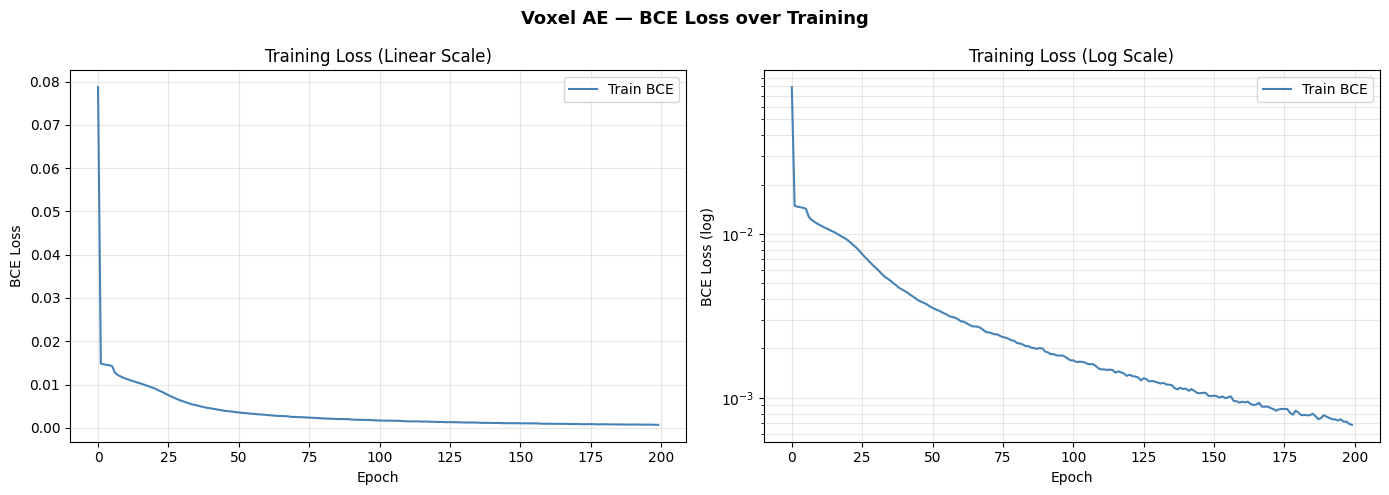

Min loss: 0.000683 at epoch 199


In [ ]:
# ── Training Loss — Linear + Log Scale ──────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(len(train_losses))

for ax, yscale, title in zip(
    axes,
    ['linear', 'log'],
    ['Training Loss (Linear Scale)', 'Training Loss (Log Scale)']
):
    ax.plot(epochs_x, train_losses, color='steelblue', linewidth=1.5, label='Train BCE')
    ax.set_yscale(yscale)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss' + (' (log)' if yscale == 'log' else ''))
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Voxel AE — BCE Loss over Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curve_log.png', dpi=150, bbox_inches='tight')
plt.show()

wandb.log({'loss_curve': wandb.Image('loss_curve_log.png')})
print(f'Min loss: {min(train_losses):.6f} at epoch {np.argmin(train_losses)}')


🔍 Reconstruction check (4 random plants):

  Sample 241 | input pts:   668 | recon pts:   671 | IoU: 0.9491
  Sample 348 | input pts:   835 | recon pts:   839 | IoU: 0.9420
  Sample 101 | input pts:   768 | recon pts:   767 | IoU: 0.9604
  Sample 318 | input pts:   828 | recon pts:   828 | IoU: 0.8991


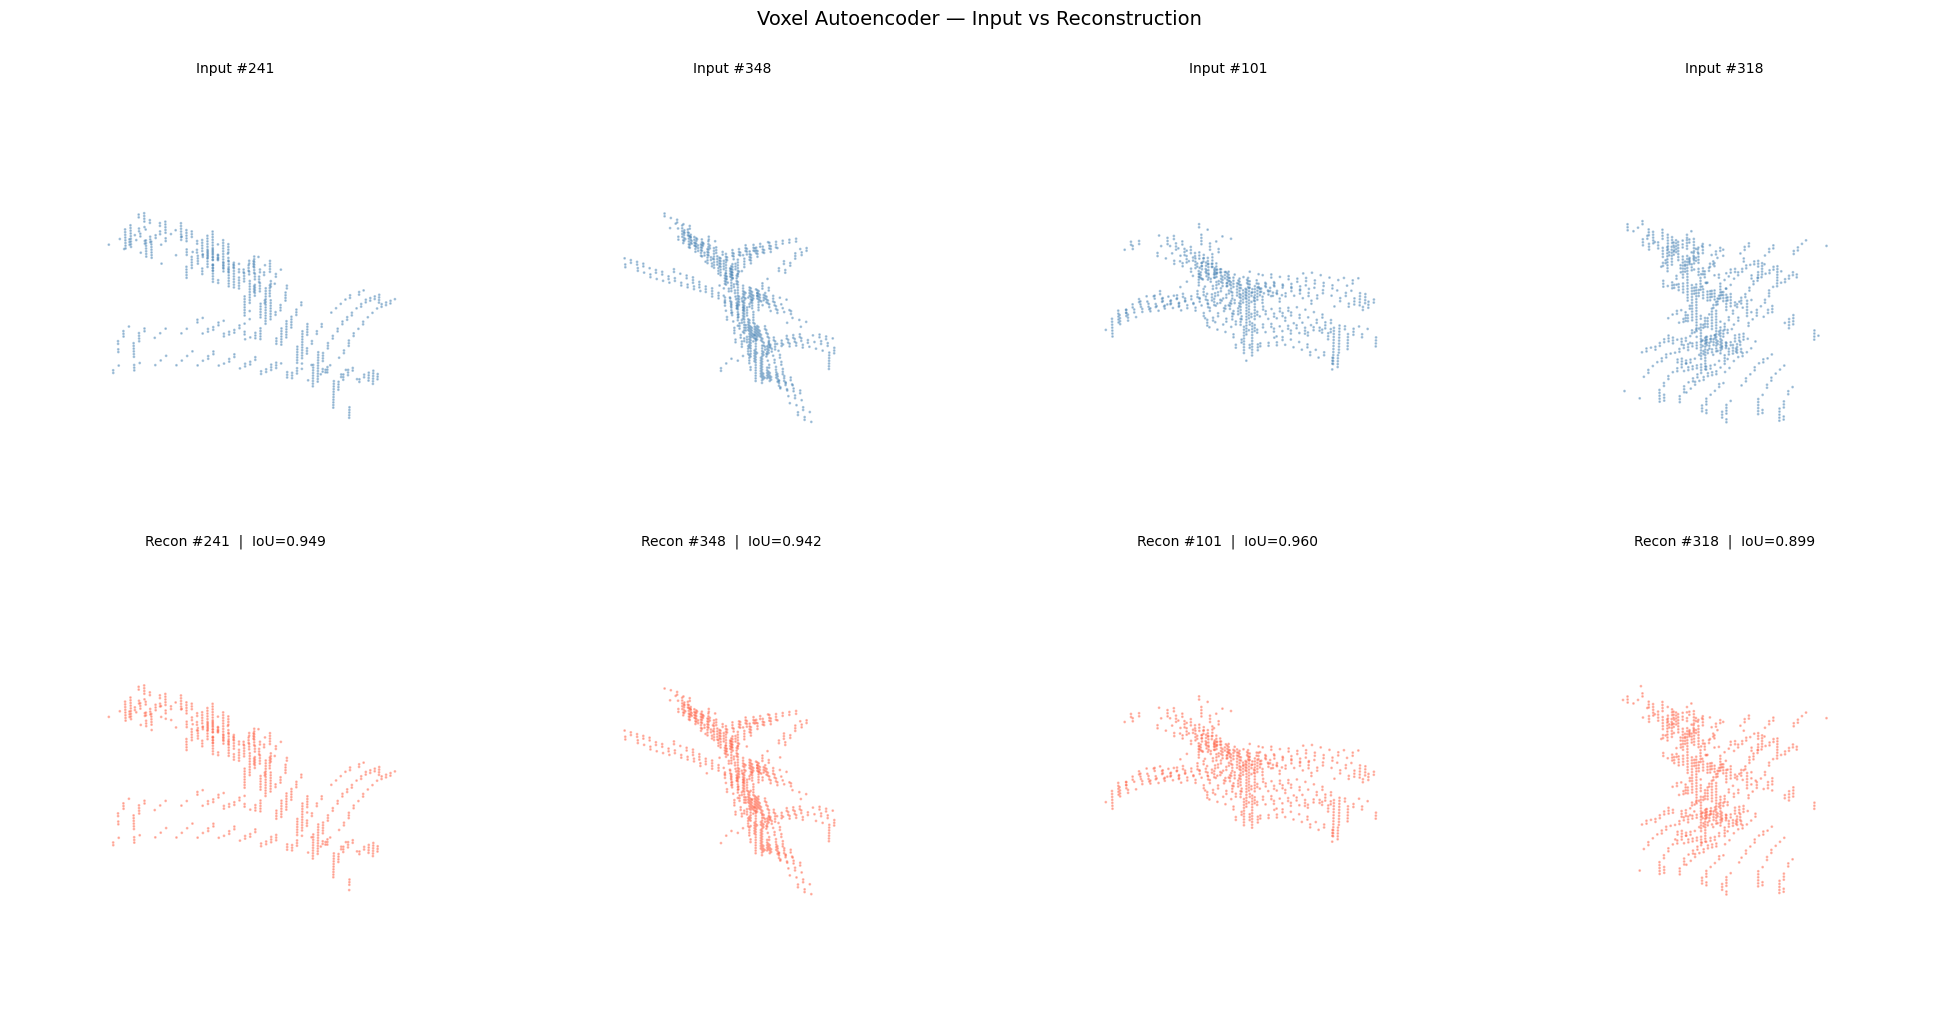

In [ ]:
# ============================================================
# RECONSTRUCTION VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

def voxel_to_pointcloud(voxel_grid, threshold=0.5):
    """Convert a voxel grid (1, D, H, W) → (N, 3) point array."""
    # squeeze out batch + channel dims → (D, H, W)
    grid = voxel_grid.squeeze().cpu().numpy()
    # get indices of occupied voxels
    coords = np.argwhere(grid > threshold)          # shape (N, 3)
    # normalize to [-1, 1] to match training space
    coords = coords / (grid.shape[0] - 1) * 2 - 1
    return coords


def visualize_reconstruction(model, dataset, device, num_samples=4, threshold=0.5, save_path=None):
    """
    For `num_samples` plants, show:
      - Input voxel occupancy (as a 3D scatter)
      - Reconstructed voxel occupancy
      - IoU score between them
    """
    model.eval()

    # ── pick random samples ────────────────────────────────
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig = plt.figure(figsize=(5 * num_samples, 10))
    fig.suptitle("Voxel Autoencoder — Input vs Reconstruction", fontsize=14, y=1.01)

    for col, idx in enumerate(indices):
        voxel = dataset[idx].unsqueeze(0).to(device)      # (1, 1, D, H, W)

        with torch.no_grad():
            recon, z = model(voxel)                        # recon: (1, 1, D, H, W)

        # ── convert to point clouds ────────────────────────
        input_pts  = voxel_to_pointcloud(voxel,  threshold)
        recon_pts  = voxel_to_pointcloud(recon,  threshold)

        # ── IoU ───────────────────────────────────────────
        input_bin = (voxel.squeeze().cpu().numpy()  > threshold).astype(bool)
        recon_bin = (recon.squeeze().cpu().numpy()  > threshold).astype(bool)
        intersection = (input_bin & recon_bin).sum()
        union        = (input_bin | recon_bin).sum()
        iou = intersection / union if union > 0 else 0.0

        # ── plot input ─────────────────────────────────────
        ax1 = fig.add_subplot(2, num_samples, col + 1, projection='3d')
        if len(input_pts) > 0:
            ax1.scatter(
                input_pts[:, 0], input_pts[:, 1], input_pts[:, 2],
                s=1, c='steelblue', alpha=0.4, rasterized=True
            )
        ax1.set_title(f"Input #{idx}", fontsize=10)
        ax1.set_axis_off()

        # ── plot reconstruction ────────────────────────────
        ax2 = fig.add_subplot(2, num_samples, num_samples + col + 1, projection='3d')
        if len(recon_pts) > 0:
            ax2.scatter(
                recon_pts[:, 0], recon_pts[:, 1], recon_pts[:, 2],
                s=1, c='tomato', alpha=0.4, rasterized=True
            )
        ax2.set_title(f"Recon #{idx}  |  IoU={iou:.3f}", fontsize=10)
        ax2.set_axis_off()

        print(f"  Sample {idx:>3} | input pts: {len(input_pts):>5} | "
              f"recon pts: {len(recon_pts):>5} | IoU: {iou:.4f}")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n💾 Saved to {save_path}")

    plt.show()


def log_reconstruction_to_wandb(model, dataset, device, num_samples=4, threshold=0.5):
    """Log input/recon side-by-side panels to W&B as a single image."""
    import wandb
    import tempfile, os

    tmp = tempfile.mktemp(suffix=".png")
    visualize_reconstruction(model, dataset, device,
                             num_samples=num_samples,
                             threshold=threshold,
                             save_path=tmp)
    wandb.log({"reconstructions": wandb.Image(tmp)})
    os.remove(tmp)
    print("✅ Logged to W&B")


# ── RUN ───────────────────────────────────────────────────────
print("🔍 Reconstruction check (4 random plants):\n")
visualize_reconstruction(
    model, dataset, device,
    num_samples=4,
    threshold=0.5
)

# optionally log to W&B (call after training loop)
# log_reconstruction_to_wandb(model, dataset, device)

  Sample 610 | input pts:   808 | recon pts:   801 | IoU: 0.9269
  Sample 471 | input pts:   802 | recon pts:   819 | IoU: 0.9483
  Sample 304 | input pts:  1314 | recon pts:  1305 | IoU: 0.8992
  Sample 673 | input pts:  1189 | recon pts:  1197 | IoU: 0.9119

💾 Saved to /tmp/tmpjowiocn1.png


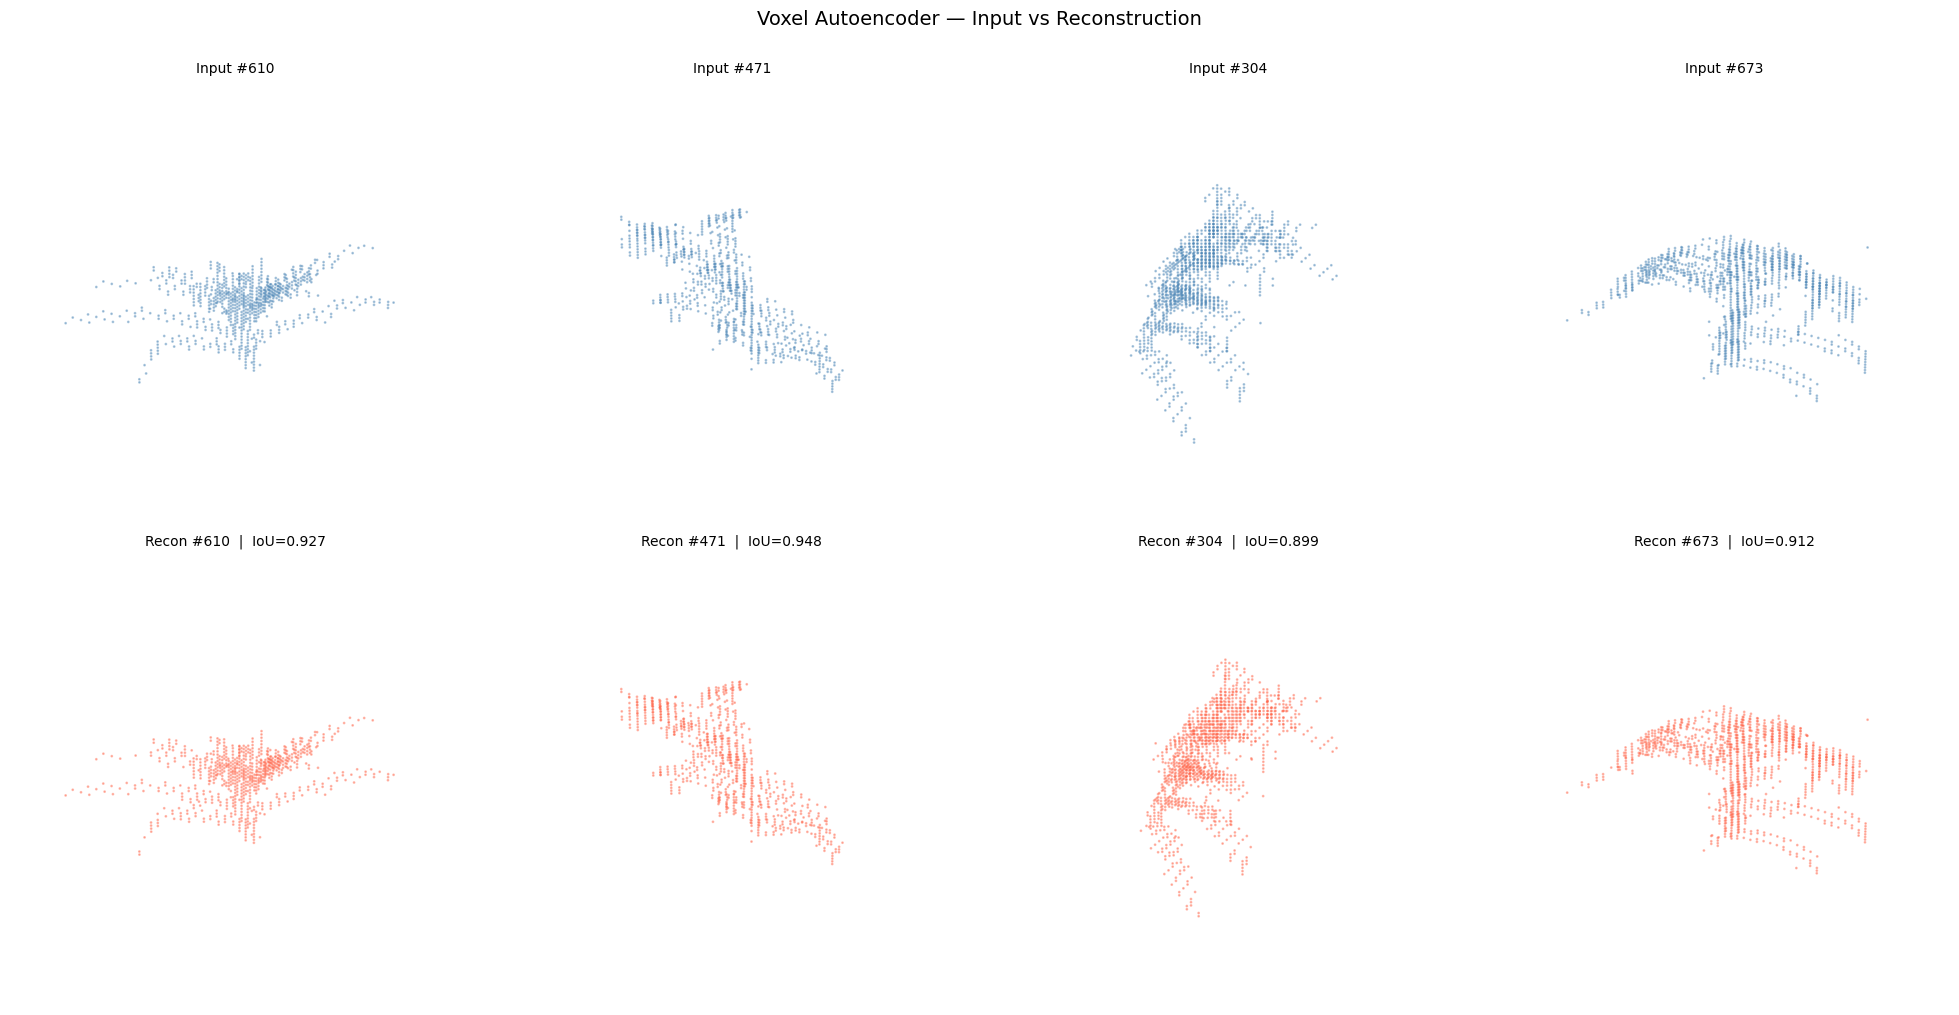

✅ Logged to W&B


In [ ]:
log_reconstruction_to_wandb(model, dataset, device)

In [ ]:
# ── Voxel → Point Cloud: Save for Cross-Model Comparison ────────────
# Converts reconstructed voxel grids to point clouds and saves
# originals.npy / reconstructions.npy matching PointNet++ / DGCNN format.

import os
import numpy as np
import torch
import open3d as o3d

N_POINTS  = 1024          # match to other models
THRESHOLD = 0.5           # voxel occupancy threshold
SAVE_DIR  = 'recon_pointclouds_voxel_ae'
os.makedirs(SAVE_DIR, exist_ok=True)

model.eval()

def voxel_to_fixed_pc(voxel_tensor, n_points, threshold=0.5):
    """Voxel grid (1,1,D,H,W) → fixed-size (n_points, 3) point cloud."""
    grid   = voxel_tensor.squeeze().cpu().numpy()   # (D, H, W)
    coords = np.argwhere(grid > threshold).astype(np.float32)  # (N, 3)
    if len(coords) == 0:
        return np.zeros((n_points, 3), dtype=np.float32)
    coords = coords / (grid.shape[0] - 1) * 2 - 1  # normalise to [-1, 1]
    if len(coords) >= n_points:
        idx = np.random.choice(len(coords), n_points, replace=False)
    else:
        idx = np.random.choice(len(coords), n_points, replace=True)
    return coords[idx]

all_originals     = []
all_reconstructed = []
all_iou           = []

for i in range(len(dataset)):
    voxel = dataset[i].unsqueeze(0).to(device)   # (1, 1, D, H, W)

    with torch.no_grad():
        recon, _ = model(voxel)

    orig_pc  = voxel_to_fixed_pc(voxel, N_POINTS, THRESHOLD)
    recon_pc = voxel_to_fixed_pc(recon, N_POINTS, THRESHOLD)

    # IoU
    orig_bin  = (voxel.squeeze().cpu().numpy() > THRESHOLD)
    recon_bin = (recon.squeeze().cpu().numpy() > THRESHOLD)
    inter = (orig_bin & recon_bin).sum()
    union = (orig_bin | recon_bin).sum()
    all_iou.append(inter / union if union > 0 else 0.0)

    all_originals.append(orig_pc)
    all_reconstructed.append(recon_pc)

    # save per-sample .ply
    for pts, tag in [(orig_pc, 'original'), (recon_pc, 'recon')]:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        o3d.io.write_point_cloud(f'{SAVE_DIR}/plant_{i:03d}_{tag}.ply', pcd)

np.save(f'{SAVE_DIR}/originals.npy',       np.stack(all_originals))       # (N,1024,3)
np.save(f'{SAVE_DIR}/reconstructions.npy', np.stack(all_reconstructed))   # (N,1024,3)
np.save(f'{SAVE_DIR}/iou_per_sample.npy',  np.array(all_iou))

print(f'Saved {len(dataset)} samples to {SAVE_DIR}/')
print(f'Mean IoU : {np.mean(all_iou):.4f}')
print(f'Std  IoU : {np.std(all_iou):.4f}')
print(f'Arrays   : {np.stack(all_originals).shape}')
print('\nLoad in any notebook with:')
print("  recon = np.load('recon_pointclouds_voxel_ae/reconstructions.npy')")


Saved 1045 samples to recon_pointclouds_voxel_ae/
Mean IoU : 0.9378
Std  IoU : 0.0204
Arrays   : (1045, 1024, 3)

Load in any notebook with:
  recon = np.load('recon_pointclouds_voxel_ae/reconstructions.npy')


In [ ]:
# ── Chamfer Distance — Voxel AE (matches DeepSDF comparison format) ──
import numpy as np
import torch

originals     = np.load(f'{SAVE_DIR}/originals.npy')       # (N, 1024, 3)
reconstructed = np.load(f'{SAVE_DIR}/reconstructions.npy') # (N, 1024, 3)

def chamfer_distance(p1: np.ndarray, p2: np.ndarray):
    """
    Returns CD-L1 and CD-L2 separately, matching the DeepSDF helper.
    p1, p2 : (M, 3)  — single shape each
    """
    t1 = torch.from_numpy(p1).float()   # (M, 3)
    t2 = torch.from_numpy(p2).float()   # (M, 3)

    diff  = t1.unsqueeze(1) - t2.unsqueeze(0)   # (M, M, 3)
    dist2 = (diff ** 2).sum(-1)                  # (M, M)

    nn_1 = dist2.min(dim=1).values   # (M,)  p1 → p2
    nn_2 = dist2.min(dim=0).values   # (M,)  p2 → p1

    cd_l2 = (nn_1.mean() + nn_2.mean()).item() / 2
    cd_l1 = (nn_1.sqrt().mean() + nn_2.sqrt().mean()).item() / 2
    return cd_l1, cd_l2

results = []

for i in range(len(originals)):
    cd_l1, cd_l2 = chamfer_distance(originals[i], reconstructed[i])
    print(f'Shape {i:3d} | CD-L1: {cd_l1:.6f} | CD-L2: {cd_l2:.6f}')
    results.append({'shape_id': i, 'cd_l1': cd_l1, 'cd_l2': cd_l2})

mean_cd_l1 = np.mean([r['cd_l1'] for r in results])
mean_cd_l2 = np.mean([r['cd_l2'] for r in results])

print(f'\n── Voxel AE Metrics ──')
print(f'Mean CD-L1 : {mean_cd_l1:.6f}')
print(f'Mean CD-L2 : {mean_cd_l2:.6f}')

np.save(f'{SAVE_DIR}/chamfer_per_sample.npy',
        np.array([[r['cd_l1'], r['cd_l2']] for r in results]))

table_rows = [[r['shape_id'], r['cd_l1'], r['cd_l2']] for r in results]
table_rows.append([None, mean_cd_l1, mean_cd_l2])

wandb.log({'pointcloud_metrics': wandb.Table(
    columns=['shape_id', 'CD-L1', 'CD-L2'],
    data=table_rows,
)})
wandb.log({'mean_cd_l1': mean_cd_l1, 'mean_cd_l2': mean_cd_l2})

print('✅ Chamfer Distance done.')

Shape   0 | CD-L1: 0.013087 | CD-L2: 0.000442
Shape   1 | CD-L1: 0.002716 | CD-L2: 0.000089
Shape   2 | CD-L1: 0.010108 | CD-L2: 0.000337
Shape   3 | CD-L1: 0.011053 | CD-L2: 0.000406
Shape   4 | CD-L1: 0.009688 | CD-L2: 0.000320
Shape   5 | CD-L1: 0.010861 | CD-L2: 0.000370
Shape   6 | CD-L1: 0.013609 | CD-L2: 0.000463
Shape   7 | CD-L1: 0.010550 | CD-L2: 0.000345
Shape   8 | CD-L1: 0.012207 | CD-L2: 0.000416
Shape   9 | CD-L1: 0.013293 | CD-L2: 0.000445
Shape  10 | CD-L1: 0.010844 | CD-L2: 0.000357
Shape  11 | CD-L1: 0.008163 | CD-L2: 0.000264
Shape  12 | CD-L1: 0.008397 | CD-L2: 0.000273
Shape  13 | CD-L1: 0.011358 | CD-L2: 0.000395
Shape  14 | CD-L1: 0.009047 | CD-L2: 0.000321
Shape  15 | CD-L1: 0.009853 | CD-L2: 0.000343
Shape  16 | CD-L1: 0.010228 | CD-L2: 0.000341
Shape  17 | CD-L1: 0.010866 | CD-L2: 0.000357
Shape  18 | CD-L1: 0.009412 | CD-L2: 0.000313
Shape  19 | CD-L1: 0.011951 | CD-L2: 0.000393
Shape  20 | CD-L1: 0.012468 | CD-L2: 0.000415
Shape  21 | CD-L1: 0.009819 | CD-L

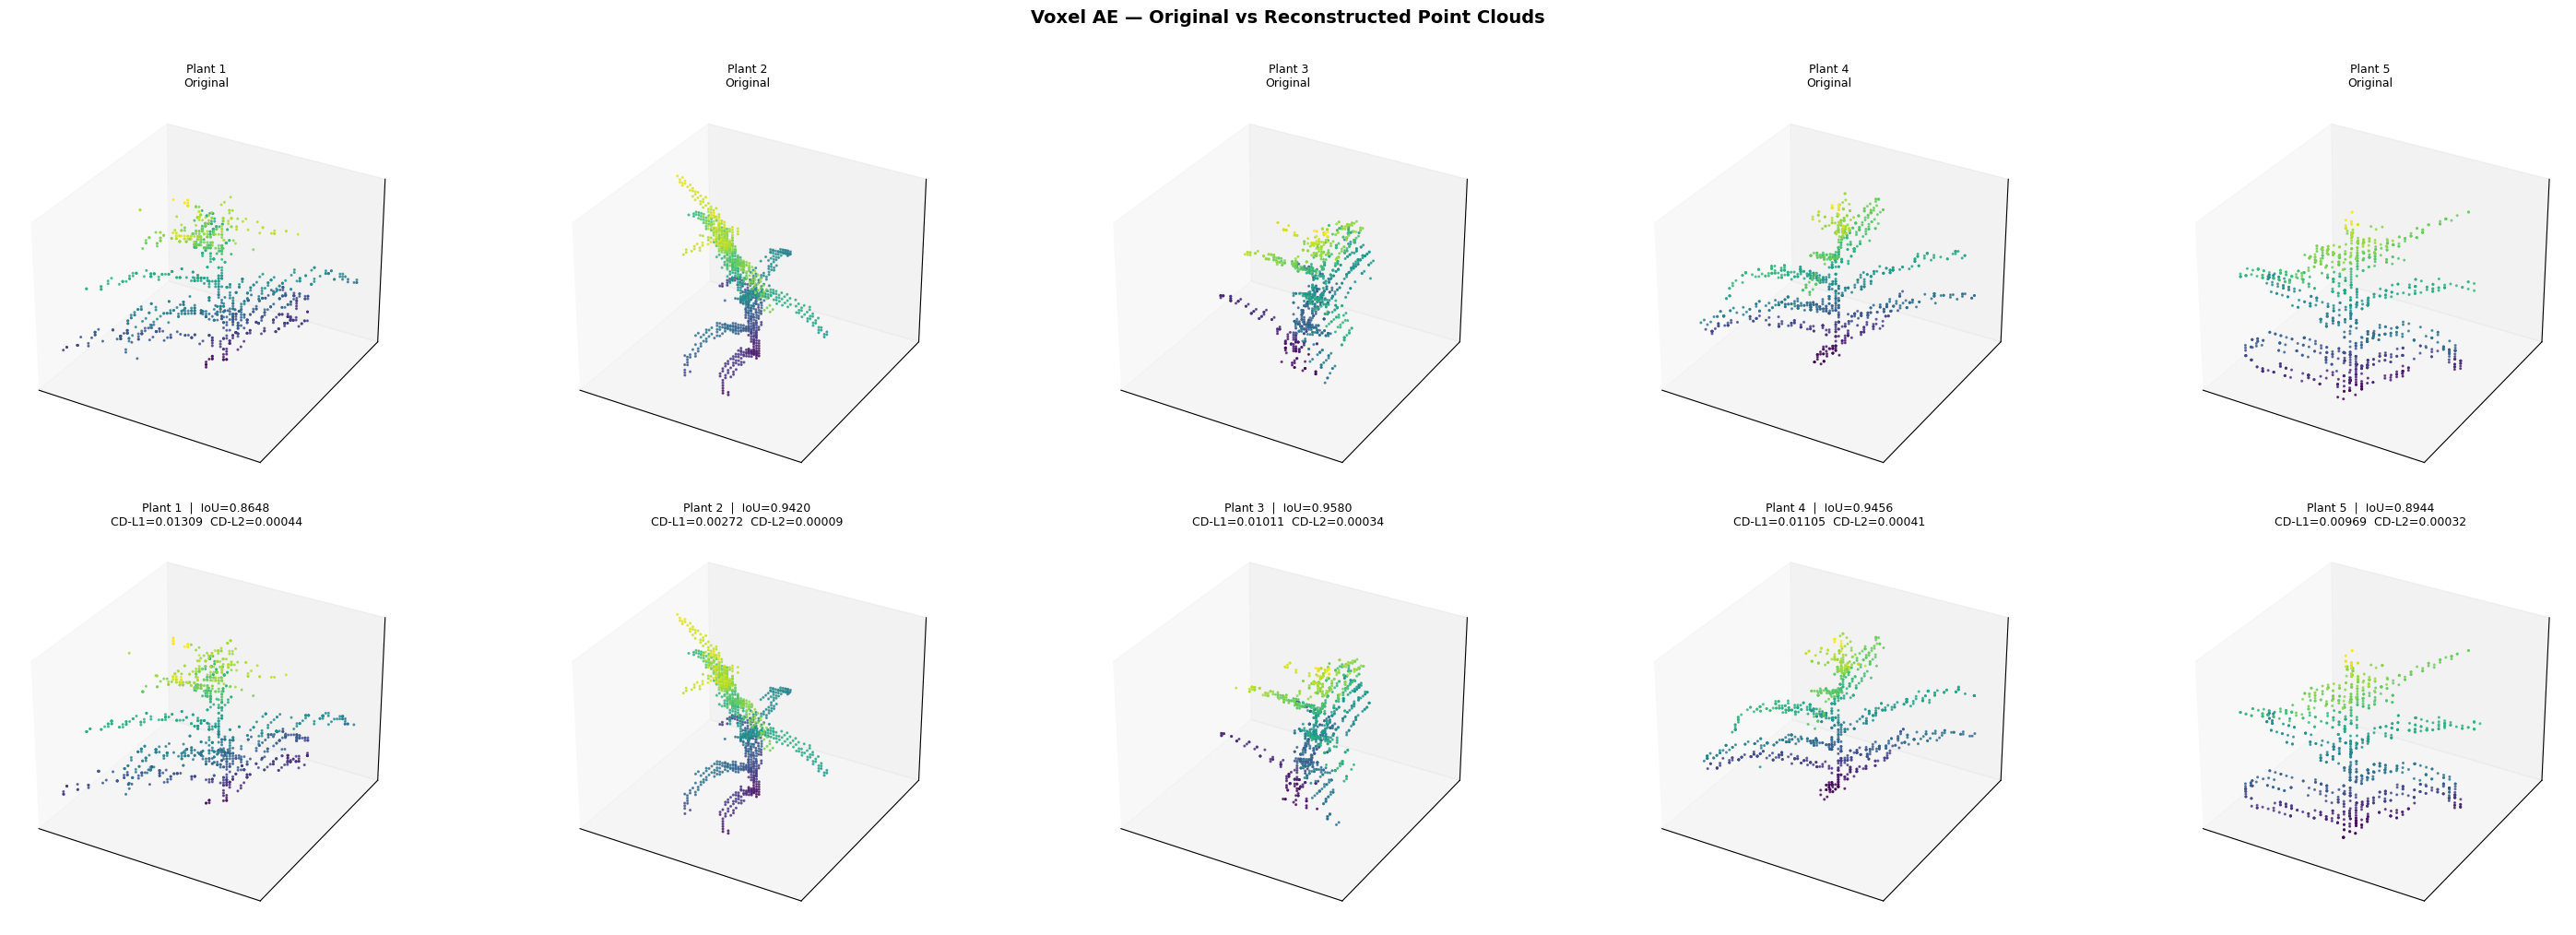

Saved to recon_pointclouds_voxel_ae/pointcloud_comparison.png


In [ ]:
# ── Visualize Original vs Reconstructed Point Clouds ────────────────
import matplotlib.pyplot as plt
import numpy as np

originals     = np.load(f'{SAVE_DIR}/originals.npy')
reconstructed = np.load(f'{SAVE_DIR}/reconstructions.npy')
ious          = np.load(f'{SAVE_DIR}/iou_per_sample.npy')
cd_data       = np.load(f'{SAVE_DIR}/chamfer_per_sample.npy')  # (N, 2) — [cd_l1, cd_l2]

N_SHOW = 5

fig = plt.figure(figsize=(6 * N_SHOW, 10))
fig.suptitle('Voxel AE — Original vs Reconstructed Point Clouds',
             fontsize=14, fontweight='bold', y=1.01)

for col in range(N_SHOW):
    orig  = originals[col]
    recon = reconstructed[col]

    vmin, vmax = orig[:, 2].min(), orig[:, 2].max()

    ax1 = fig.add_subplot(2, N_SHOW, col + 1, projection='3d')
    ax1.scatter(orig[:, 0], orig[:, 1], orig[:, 2],
                s=1.5, alpha=0.7, c=orig[:, 2], cmap='viridis', vmin=vmin, vmax=vmax)
    ax1.set_title(f'Plant {col+1}\nOriginal', fontsize=9)
    ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])

    ax2 = fig.add_subplot(2, N_SHOW, N_SHOW + col + 1, projection='3d')
    ax2.scatter(recon[:, 0], recon[:, 1], recon[:, 2],
                s=1.5, alpha=0.7, c=recon[:, 2], cmap='viridis', vmin=vmin, vmax=vmax)
    ax2.set_title(
        f'Plant {col+1}  |  IoU={ious[col]:.4f}\n'
        f'CD-L1={cd_data[col,0]:.5f}  CD-L2={cd_data[col,1]:.5f}',
        fontsize=9,
    )
    ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/pointcloud_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {SAVE_DIR}/pointcloud_comparison.png')

In [ ]:
# ── Visualize Chamfer Distance — Voxel AE vs DeepSDF ────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# ── Per-sample bar chart ─────────────────────────────────────────────
shape_ids = [r['shape_id'] for r in results]
cd_l1_vals = [r['cd_l1'] for r in results]
cd_l2_vals = [r['cd_l2'] for r in results]

fig_cd = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Chamfer Distance — L1', 'Chamfer Distance — L2'),
    horizontal_spacing=0.12,
)

for col, (vals, name, color) in enumerate([
    (cd_l1_vals, 'CD-L1', '#00CC96'),
    (cd_l2_vals, 'CD-L2', '#636EFA'),
], start=1):
    fig_cd.add_trace(go.Bar(
        x=shape_ids,
        y=vals,
        name=name,
        marker_color=color,
        text=[f'{v:.5f}' for v in vals],
        textposition='outside',
        showlegend=False,
    ), row=1, col=col)

    # mean line
    mean_val = np.mean(vals)
    fig_cd.add_hline(
        y=mean_val,
        line_dash='dash',
        line_color='tomato',
        annotation_text=f'mean={mean_val:.5f}',
        annotation_position='top right',
        row=1, col=col,
    )

fig_cd.update_layout(
    title='Voxel AE — Chamfer Distance per Sample',
    template='plotly_dark',
    height=480,
    xaxis_title='Shape ID',
    xaxis2_title='Shape ID',
    yaxis_title='CD-L1',
    yaxis2_title='CD-L2',
)
fig_cd.show()
wandb.log({'chamfer_bar': wandb.Plotly(fig_cd)})

# ── Distribution (histogram) ─────────────────────────────────────────
fig_hist = go.Figure()
for vals, name, color in [
    (cd_l1_vals, 'CD-L1', '#00CC96'),
    (cd_l2_vals, 'CD-L2', '#636EFA'),
]:
    fig_hist.add_trace(go.Histogram(
        x=vals,
        name=name,
        marker_color=color,
        opacity=0.7,
        nbinsx=20,
    ))

fig_hist.update_layout(
    title='Voxel AE — Chamfer Distance Distribution',
    template='plotly_dark',
    barmode='overlay',
    xaxis_title='Chamfer Distance',
    yaxis_title='Count',
    height=400,
)
fig_hist.show()
wandb.log({'chamfer_hist': wandb.Plotly(fig_hist)})